We've just went through linear regression, which is for predicting continuous values such as -1.52, 2.53, ... , 6.87.

You may come up with some values that have continuous scales: Energy Consumption, Price, Mass, and Density.


--- 

However, what if the variable you want to predict is discrete? 

Such as (i) pass or fail in exam, (ii) head or tail in coin toss, and (iii) animal or plant?

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/logitsic_intro.png" width="1000" alt="logitsic_intro">
* This image has been generated using ChatGPT.

# Logistic Regression

- Logistic regression is a statistical model used for binary classification tasks. 
- It predicts the probability of an event belonging to one of two classes. 
- The model uses the sigmoid (logistic) function to transform the linear combination of features into a probability value between 0 and 1. 
- The coefficients associated with each feature are learned during training, and predictions are made by applying these coefficients to new data. 

- Logistic regression is widely used in various domains and offers interpretability, but assumes a linear relationship between features and the log-odds of the target variable.

### Import libraries and initialize random generator

In [1]:
import numpy as np
np.random.seed(0)

### Example 1: Linearly Separable Data
We will use the sklearn library to generate two clusters of random data.

Text(1, 0.25, 'y = 0')

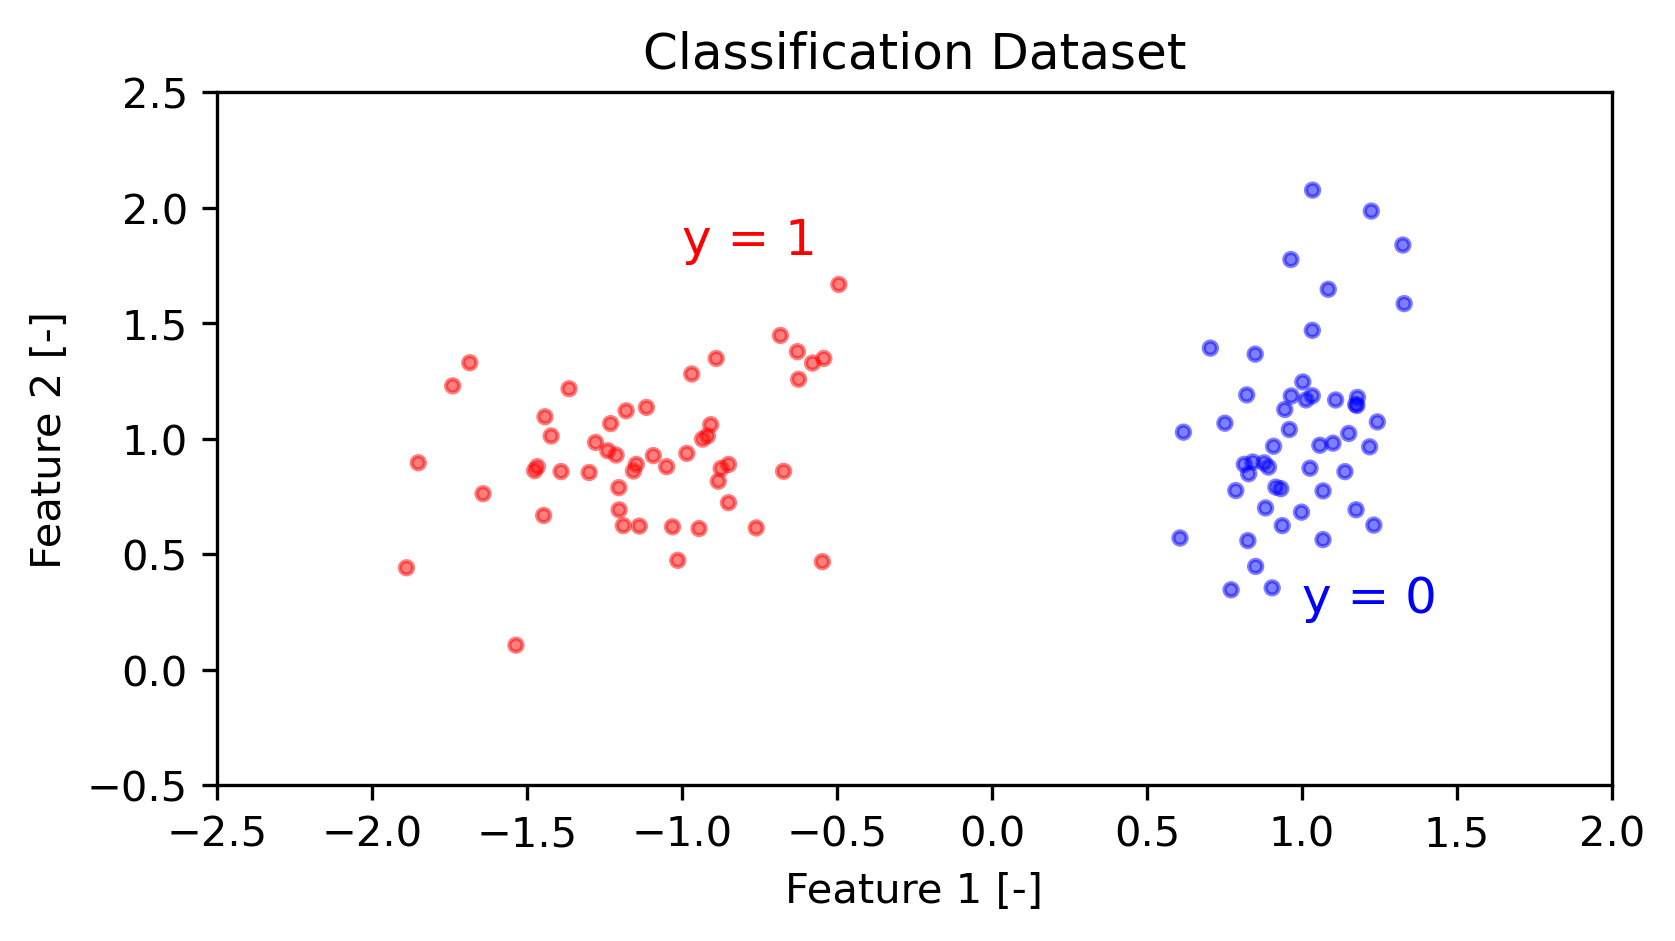

In [2]:
from sklearn.datasets import make_classification

# Generate the dataset
X, y = make_classification(n_features=2, n_redundant=0,
                           n_informative=2, random_state=1,
                           n_clusters_per_class=1)

# Plot the data points
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3), dpi = 300)

ax.set_xlim(-2.5, 2); ax.set_ylim(-0.5, 2.5)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=10,  alpha=0.5)
ax.set_xlabel('Feature 1 [-]')
ax.set_ylabel('Feature 2 [-]')
ax.set_title('Classification Dataset')

ax.text(-1, 1.8, 'y = 1', color='red', fontsize=12)
ax.text(1, 0.25, 'y = 0', color='blue', fontsize=12)

# for i, label in enumerate(y):
#     ax.annotate(label, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')

The task in one picture: use the two features to predict the class.

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/logistic-task.png" width="640" alt="logistic-task">

## Logistics Regression Classifier

### sigmoid function
In binary classification, it is desirable for the hypothesis function ($\hat{y}$) to produce output values between 0 and 1. To achieve this, we can employ the sigmoid function, which effectively compresses the input values within the desired range.

<img src="https://raw.githubusercontent.com/MLcmore2023/MLcmore2023/main/.images/logistic_regression1.png" alt="Image Description" width="78%">

The output of the sigmoid is interpreted as a **probability** — specifically, the probability that an instance belongs to the positive class ($y = 1$):

$$\hat{y} = \sigma(z) = P(y = 1 \mid x).$$

So if the sigmoid returns $0.9$ for a data instance, the model is saying that instance is $90\%$ likely to be class $1$ and $10\%$ likely to be class $0$.

The plot below overlays the sigmoid curve on the labeled points to show this mapping:

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/sigmoid.png" width="560" alt="sigmoid">


In [3]:
def sigmoid(z):
    return 1.0/(1 + np.exp(-z))

### Model Training
In logistic regression, the prediction is $$\hat{y} = \sigma(w \cdot X + b)$$
where $\sigma(\cdot)$ is the sigmoid function, and $\omega$ is the weights vector X.


The loss function is: $$
\text{Loss}(y, \hat{y}) = -\frac{1}{N}\sum_{i=1}^{N} \left( y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right)$$


**What this loss means.** Binary cross-entropy measures how far the predicted probabilities $\hat{y}$ are from the true labels $y$. Since every label is either $0$ or $1$, only one term in the sum is active per example:

- **If $y_i = 1$:** the term becomes $-\log(\hat{y}_i)$ — close to $0$ when $\hat{y}_i \to 1$ (confident and right), but shooting up to $+\infty$ as $\hat{y}_i \to 0$ (confident and wrong).
- **If $y_i = 0$:** only $-\log(1 - \hat{y}_i)$ survives — close to $0$ when $\hat{y}_i \to 0$, and $+\infty$ as $\hat{y}_i \to 1$.

So the loss stays low for correct, confident predictions and grows without bound for confident mistakes; it is minimized when $\hat{y}_i \to y_i$ for every example. This is not an arbitrary choice: minimizing cross-entropy is exactly the same as maximizing the likelihood of the data under a Bernoulli model (it is the *negative log-likelihood*), which is why it is the natural loss for classification. We use it instead of the mean squared error (MSE) from linear regression because MSE combined with the sigmoid is non-convex and produces flat, weak gradients that stall training, whereas cross-entropy keeps the problem convex with strong gradients.

In [4]:
#this code is optional, and only used for visualization or progress monitoring during training
def loss(y, y_hat):
    loss = -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))
    return loss

confident and RIGHT -> tiny loss;  confident and WRONG -> huge loss

true y = 1,  predicted y_hat = 0.99  ->  loss =  0.010
true y = 1,  predicted y_hat = 0.60  ->  loss =  0.511
true y = 1,  predicted y_hat = 0.50  ->  loss =  0.693
true y = 1,  predicted y_hat = 0.10  ->  loss =  2.303
true y = 1,  predicted y_hat = 0.01  ->  loss =  4.605
true y = 0,  predicted y_hat = 0.01  ->  loss =  0.010
true y = 0,  predicted y_hat = 0.99  ->  loss =  4.605


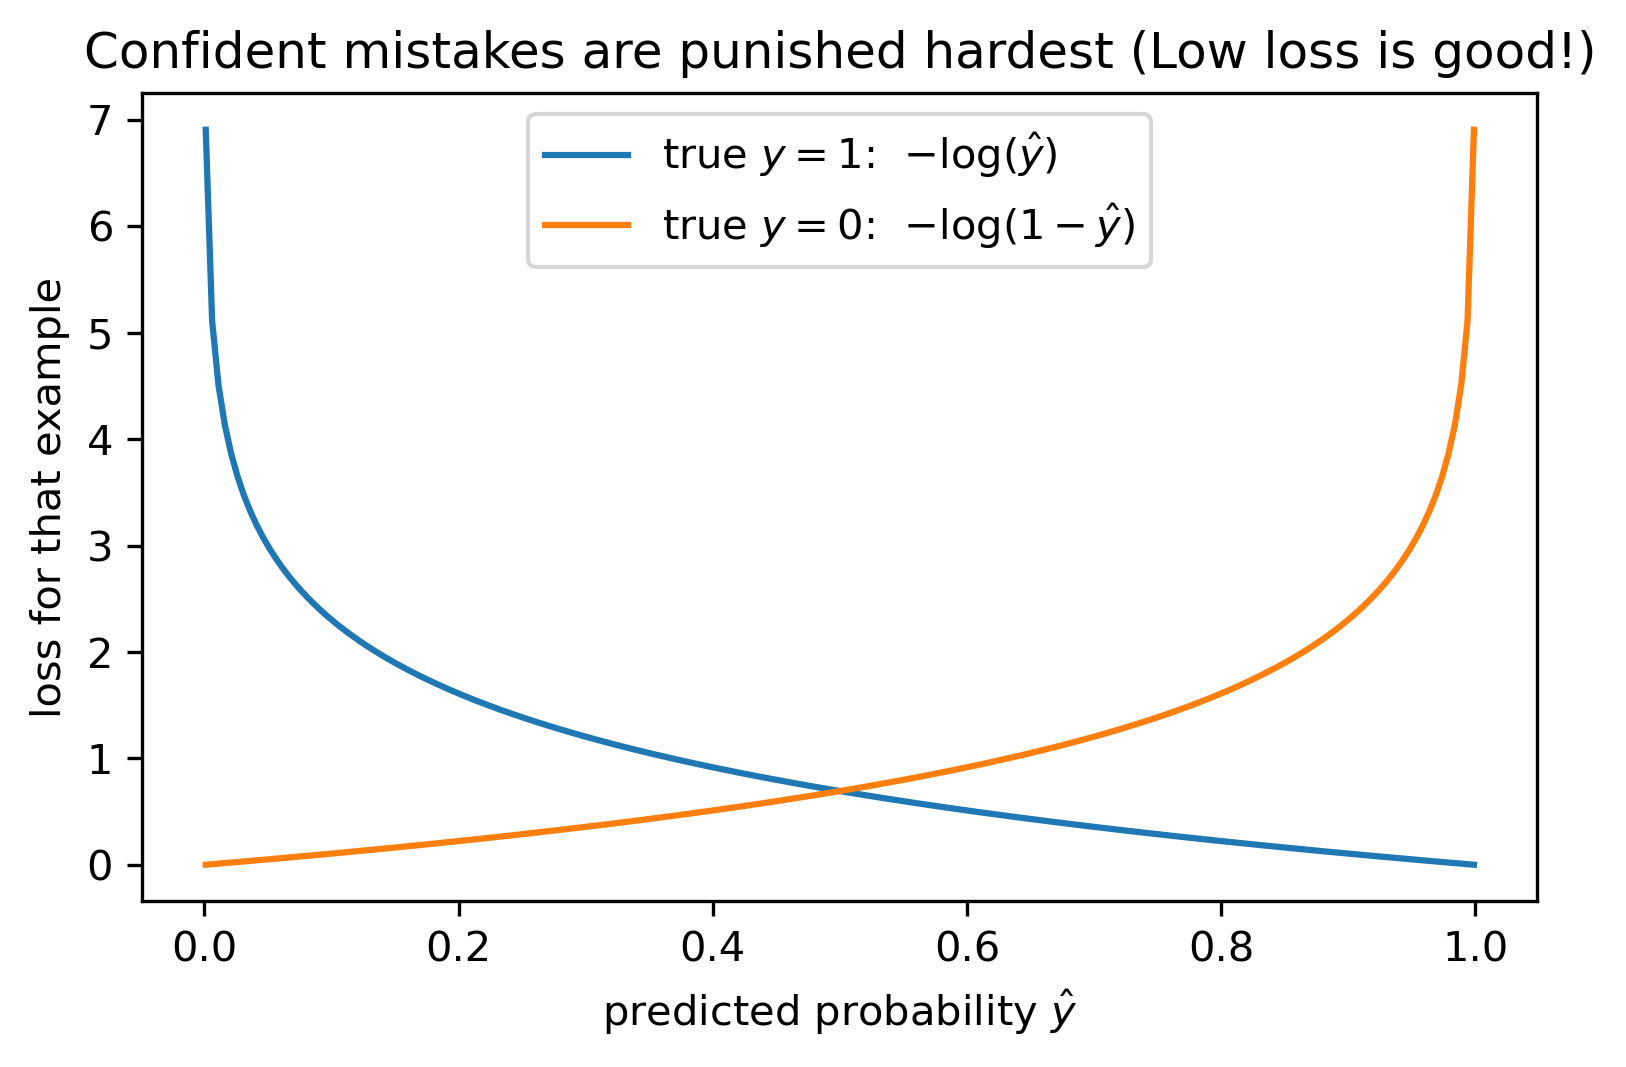

In [5]:
# How the loss behaves: feed a few hand-picked predictions through it.
print("confident and RIGHT -> tiny loss;  confident and WRONG -> huge loss\n")
for y_true, y_pred in [(1, 0.99), (1, 0.6), (1, 0.5), (1, 0.1), (1, 0.01),
                       (0, 0.01), (0, 0.99)]:
    L = loss(np.array([y_true]), np.array([y_pred]))
    print(f"true y = {y_true},  predicted y_hat = {y_pred:4.2f}  ->  loss = {L:6.3f}")

# The two penalty curves behind those numbers.
p = np.linspace(0.001, 0.999, 200)
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)
ax.plot(p, -np.log(p), label=r'true $y=1$:  $-\log(\hat{y})$')
ax.plot(p, -np.log(1 - p), label=r'true $y=0$:  $-\log(1-\hat{y})$')
ax.set_xlabel(r'predicted probability $\hat{y}$')
ax.set_ylabel('loss for that example')
ax.set_title('Confident mistakes are punished hardest (Low loss is good!)')
ax.legend()
plt.show()

### Calculating Gradient

Unlike linear regression (OLS), logistic regression has **no closed-form solution** for its parameters — we cannot simply solve a formula for the best $w$ and $b$. Instead, we train the model **iteratively** with gradient descent, taking small steps that gradually reduce the loss we defined above.

To take a step, we first need to know which direction reduces the loss. That information comes from the **gradient** — the partial derivatives of the loss with respect to each weight $w$ and the bias $b$. Each derivative tells us how much the loss changes when we nudge that parameter, so moving *against* the gradient moves us toward a smaller loss.

dw is the partial derivative of the Loss function with respect to w and db is the partial derivative of the Loss function with respect to b

$$
\frac{\partial \text{Loss}}{\partial w_j} = \frac{1}{N}\sum_{i=1}^{N} (\hat{y}_i - y_i) x_{ij} $$

$$
\frac{\partial \text{Loss}}{\partial b} = \frac{1}{N}\sum_{i=1}^{N} (\hat{y}_i - y_i)
$$

In [6]:
def gradients(X, y, y_hat):
    # number of training examples.
    n = X.shape[0]

    # Gradient of loss with respect to weights.
    dw = (1/n)*np.dot(X.T, (y_hat - y))

    # Gradient of loss with respect to bias.
    db = (1/n)*np.sum((y_hat - y))

    return dw, db

### Gradient Descent
1. Initialize the weights and biases with zeros
2. Compute the gradient of the cost function in respect to the weights and biases for all training examples. (i.e. computing how we should change the weights and biases so that the network is less wrong in all training examples)
3. Now we know how we should change the weights and biases so that the network is less wrong, we use this gradient to update the weights and biases (minus the weights and biases by the gradients times a tiny number called learning rate)
4. Repeat for as many times as time and computation resource permits


The update rule — take a small step *against* the gradient, scaled by the **learning rate** $\alpha$:

$$ w \leftarrow w - \alpha\,\frac{\partial \text{Loss}}{\partial w} = w - \alpha\,dw
\qquad\qquad
b \leftarrow b - \alpha\,\frac{\partial \text{Loss}}{\partial b} = b - \alpha\,db $$

$dw$ and $db$ are exactly what the `gradients` function above computes. One pass of this update over the whole training set is an **epoch**; repeating it for many epochs shrinks the loss step by step.

In [7]:
def initialize_weights_and_biases(X):
    global num_of_training_examples, num_of_features
    num_of_training_examples, num_of_features = X.shape
    w = np.zeros((num_of_features,1))
    b = 0
    return w, b

def gradient_descent(X, y):
    w,b =initialize_weights_and_biases(X)

    # Standardize input
    X = (X - X.mean(axis=0))/X.std(axis=0)

    # Reshaping y to allow matrix multiplication
    y = y.reshape(num_of_training_examples,1)

    losses = [] #optional. This is just for visualization / monitoring
    num_of_epochs=1000
    learning_rate=0.01
    for epoch in range(num_of_epochs):

        # Calculating hypothesis/prediction.
        y_hat = sigmoid(np.dot(X, w) + b)

        # Getting the gradients of loss with respect to parameters.
        dw, db = gradients(X, y, y_hat)

        # Updating the parameters.
        w -= learning_rate*dw
        b -= learning_rate*db

        #optional. This is just for visualization / monitoring
        # Calculating loss and appending it in the list.
        l = loss(y, sigmoid(np.dot(X, w) + b))
        losses.append(l)
    return w, b

### Prediction function
The way we defined hypothesis is the probability of y being 1 given X and parameterized by w and b. So, we will say that it will make a prediction of y=1 when y_hat ≥ 0.5, and  y=0 when y_hat < 0.5

In [8]:
def predict(X, w, b):
    # Normalizing the inputs.
    X = (X - X.mean(axis=0))/X.std(axis=0)

    # Calculating presictions/y_hat.
    predictions = sigmoid(np.dot(X, w) + b)

    y_pred = []
    # if y_hat >= 0.5 --> round up to 1.  if y_hat < 0.5 --> round up to 1
    for prediction in predictions:
        if prediction > 0.5:
            y_pred.append(1)
        else:
            y_pred.append(0)

    return np.array(y_pred)

### Evaluation accuracy
We get an accuracy of 100%. We can see from the above decision boundary graph that we are able to separate the green and blue classes perfectly.

In [9]:
weights, biases = gradient_descent(X,y)
y_hat = predict(X, weights, biases)

total_elements = len(y.flatten())
correct_predictions = 0

for i in range(total_elements):
    if y.flatten()[i] == y_hat[i]:
        correct_predictions += 1

accuracy = correct_predictions / total_elements
print(accuracy)

1.0


### Visualize result

The decision boundary is where the model flips its vote, i.e. where $\sigma(w\cdot x + b)=0.5$, which happens exactly when $w\cdot x + b = 0$. 

- For two features that is $w_0 x_1 + w_1 x_2 + b = 0$; solving for $x_2$ gives $x_2 = -\frac{w_0}{w_1}\,x_1 - \frac{b}{w_1}$. 
- Comparing with $x_2 = m\,x_1 + c$, we read off the **slope** $m=-w_0/w_1$ and the **intercept** $c=-b/w_1$. (Caveat: `w,b` were fit on standardized features, so the line lives in standardized space and is only approximate on the raw axes — and being straight, it can never curve around the moons in Example 2.)


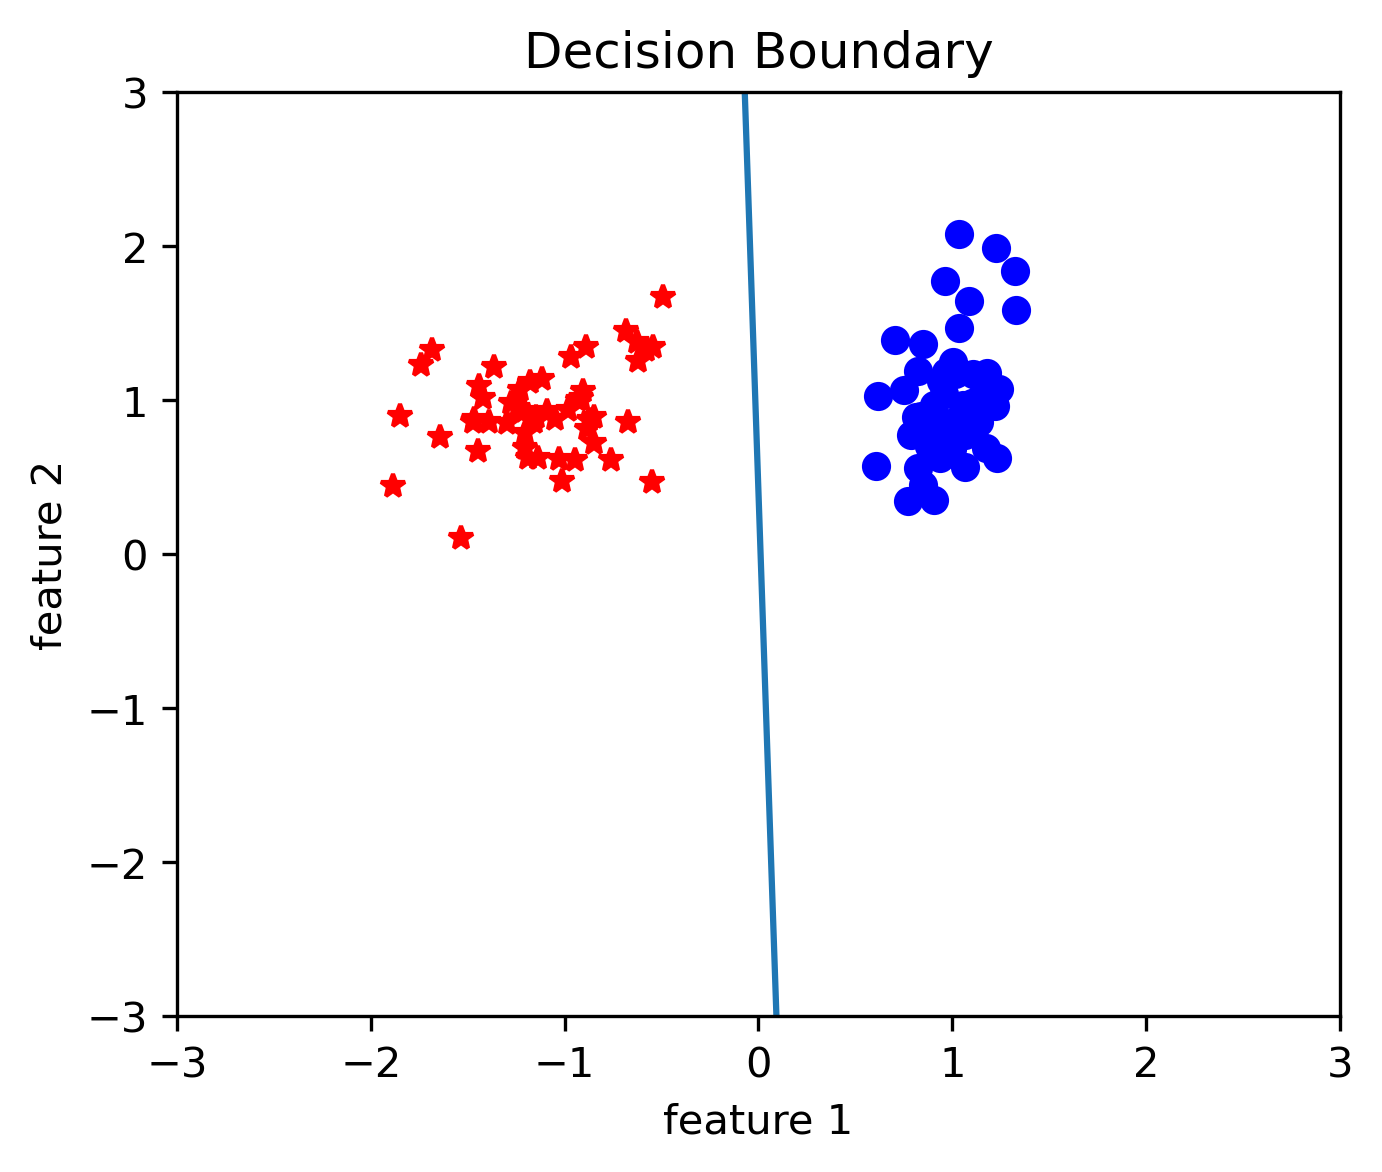

In [10]:
def plot_decision_boundary(X, y, w, b):
    # --- graph the boundary line ---
    # The decision boundary is where the model is "undecided", i.e. where
    #     sigmoid(w·x + b) = 0.5   <=>   w·x + b = 0.
    # With two features that is:   w0*x1 + w1*x2 + b = 0.
    # Solving this straight line for x2 (the vertical-axis feature):
    #     x2 = -(w0/w1)*x1  -  b/w1
    # Matching it to the classic line "x2 = m*x1 + c" lets us read off:
    #     m (slope)     = -w0 / w1
    #     c (intercept) = -b  / w1
    x1 = np.array([min(X[:,0]), max(X[:,0])])   # two x-values (left & right edges) are enough to draw a line
    m = -w[0]/w[1]                    # slope     = -w0 / w1
    c = -b/w[1]                       # intercept = -b  / w1
    x2 = m*x1 + c                     # matching x2 for each x1 that sits on the boundary
    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    ax.plot(x1, x2, '-')             # - means line style is straight line
    # CAVEAT: w,b were learned on STANDARDIZED features (gradient_descent standardizes X
    # internally), so this line is really drawn in standardized space and is only approximate
    # on the raw axes. And being a straight line, it can NEVER bend around the two interleaved
    # moons in Example 2 -- that limitation is exactly what the polynomial-feature step fixes.

    # Plot the points
    feature1 = X[:, 0]
    feature2 = X[:, 1]
    ax.set_xlim([-3, 3]); ax.set_ylim([-3, 3])
    ax.plot(feature1[y==0], feature2[y==0], "bo") # b means blue, o means round points
    ax.plot(feature1[y==1], feature2[y==1], "r*") # r means red, * means star points
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.set_title('Decision Boundary')

plot_decision_boundary(X, y_hat, weights, biases)

### Visualizing predictions as a probability surface (3D)

For a better understanding, we can plot them on 3D. 

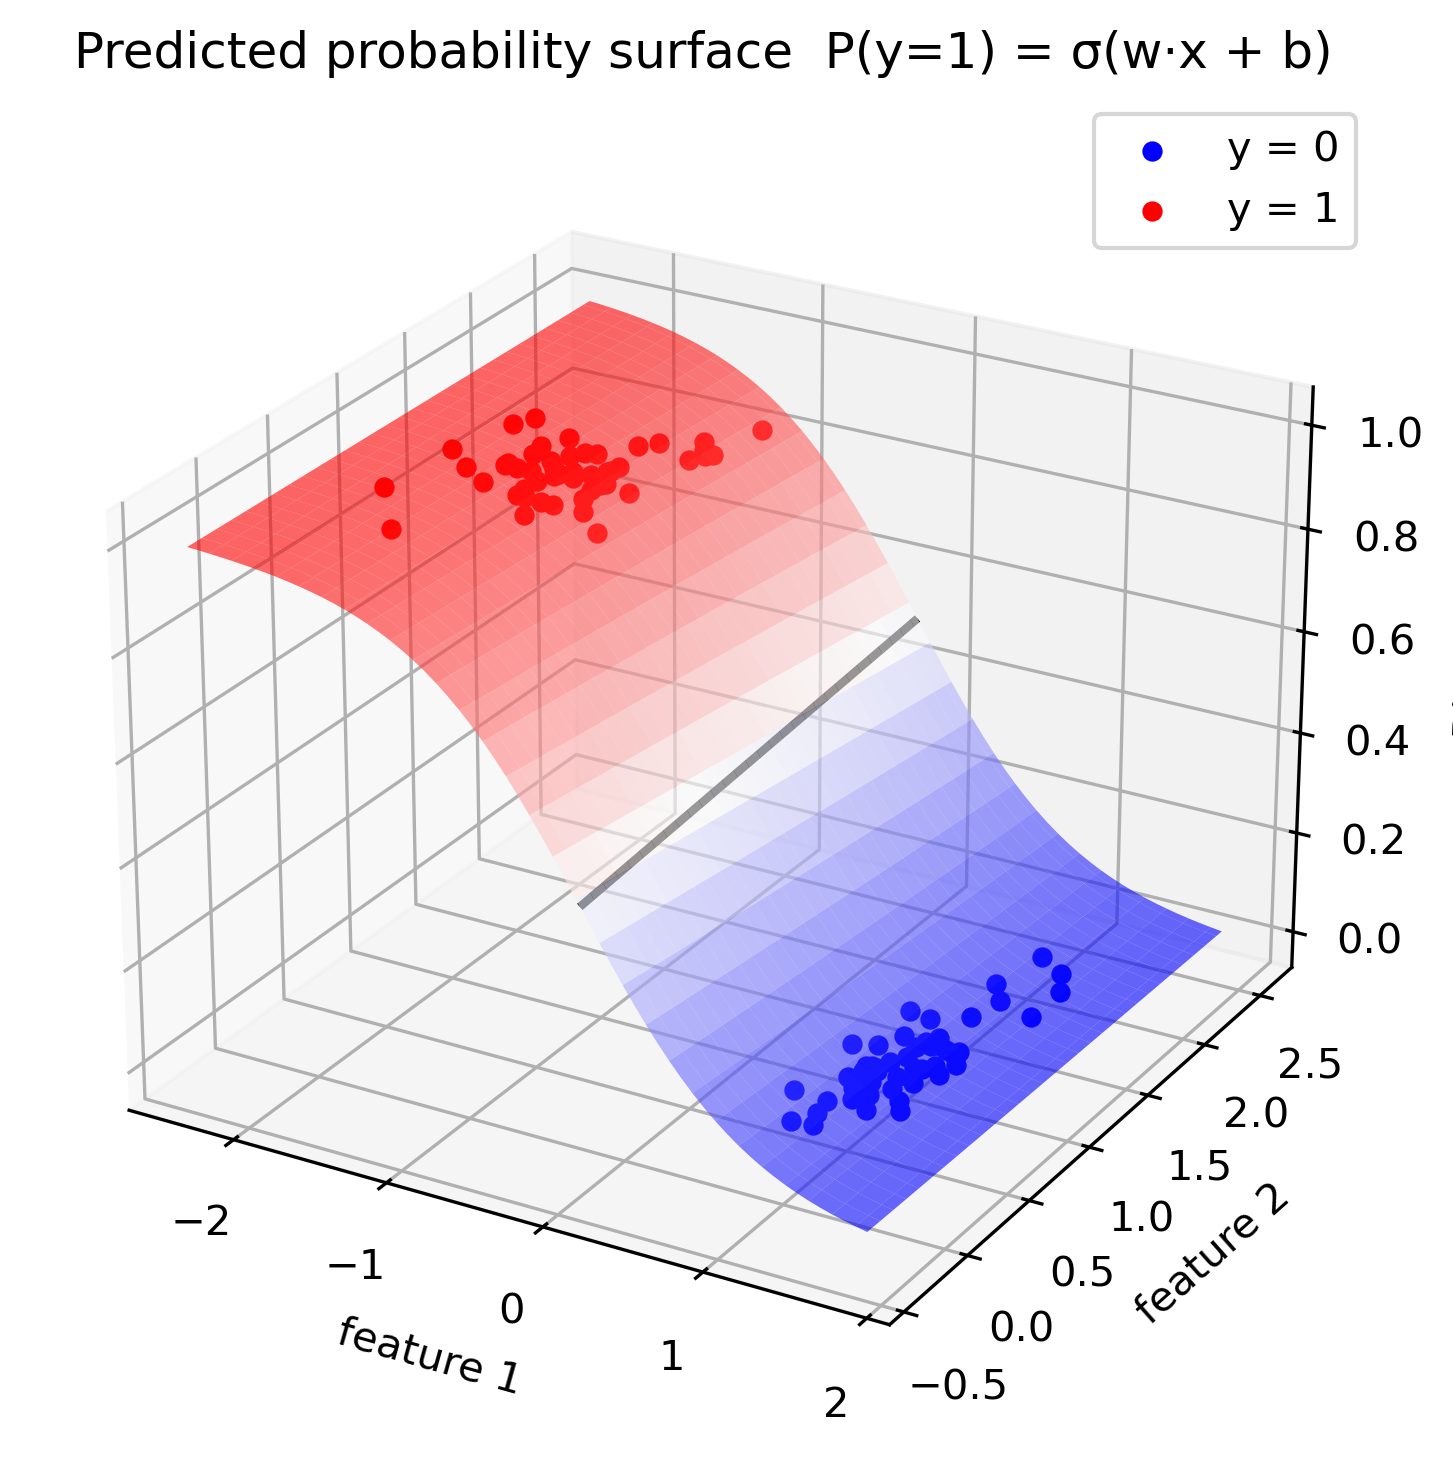

In [11]:
# 3D surface of the predicted probability  P(y=1) = sigmoid(w·x + b)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the '3d' projection)
import matplotlib.pyplot as plt

# w,b were learned on STANDARDIZED features, so standardize the grid with the TRAINING mean/std
mu, sd = X.mean(axis=0), X.std(axis=0)
x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 60)
x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 60)
XX, YY = np.meshgrid(x1, x2)
grid = (np.c_[XX.ravel(), YY.ravel()] - mu) / sd
ZZ = sigmoid(grid @ weights + biases).reshape(XX.shape)   # P(y=1) at every grid point

fig, ax = plt.subplots(figsize=(7, 5), dpi=300, subplot_kw={'projection': '3d'})
ax.plot_surface(XX, YY, ZZ, cmap='bwr', alpha=0.6, edgecolor='none')
ax.contour(XX, YY, ZZ, levels=[0.5], colors='k', linewidths=2, offset=0.5)   # decision boundary
ax.scatter(X[y == 0, 0], X[y == 0, 1], 0, color='blue', s=15, depthshade=False, label='y = 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], 1, color='red',  s=15, depthshade=False, label='y = 1')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2'); ax.set_zlabel('P(y=1)')
ax.set_title('Predicted probability surface  P(y=1) = σ(w·x + b)')
ax.view_init(elev=25, azim=-60)
ax.legend()
plt.tight_layout()
plt.show()

### Example 2: Non-linearly Separable Data

In [12]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.12)

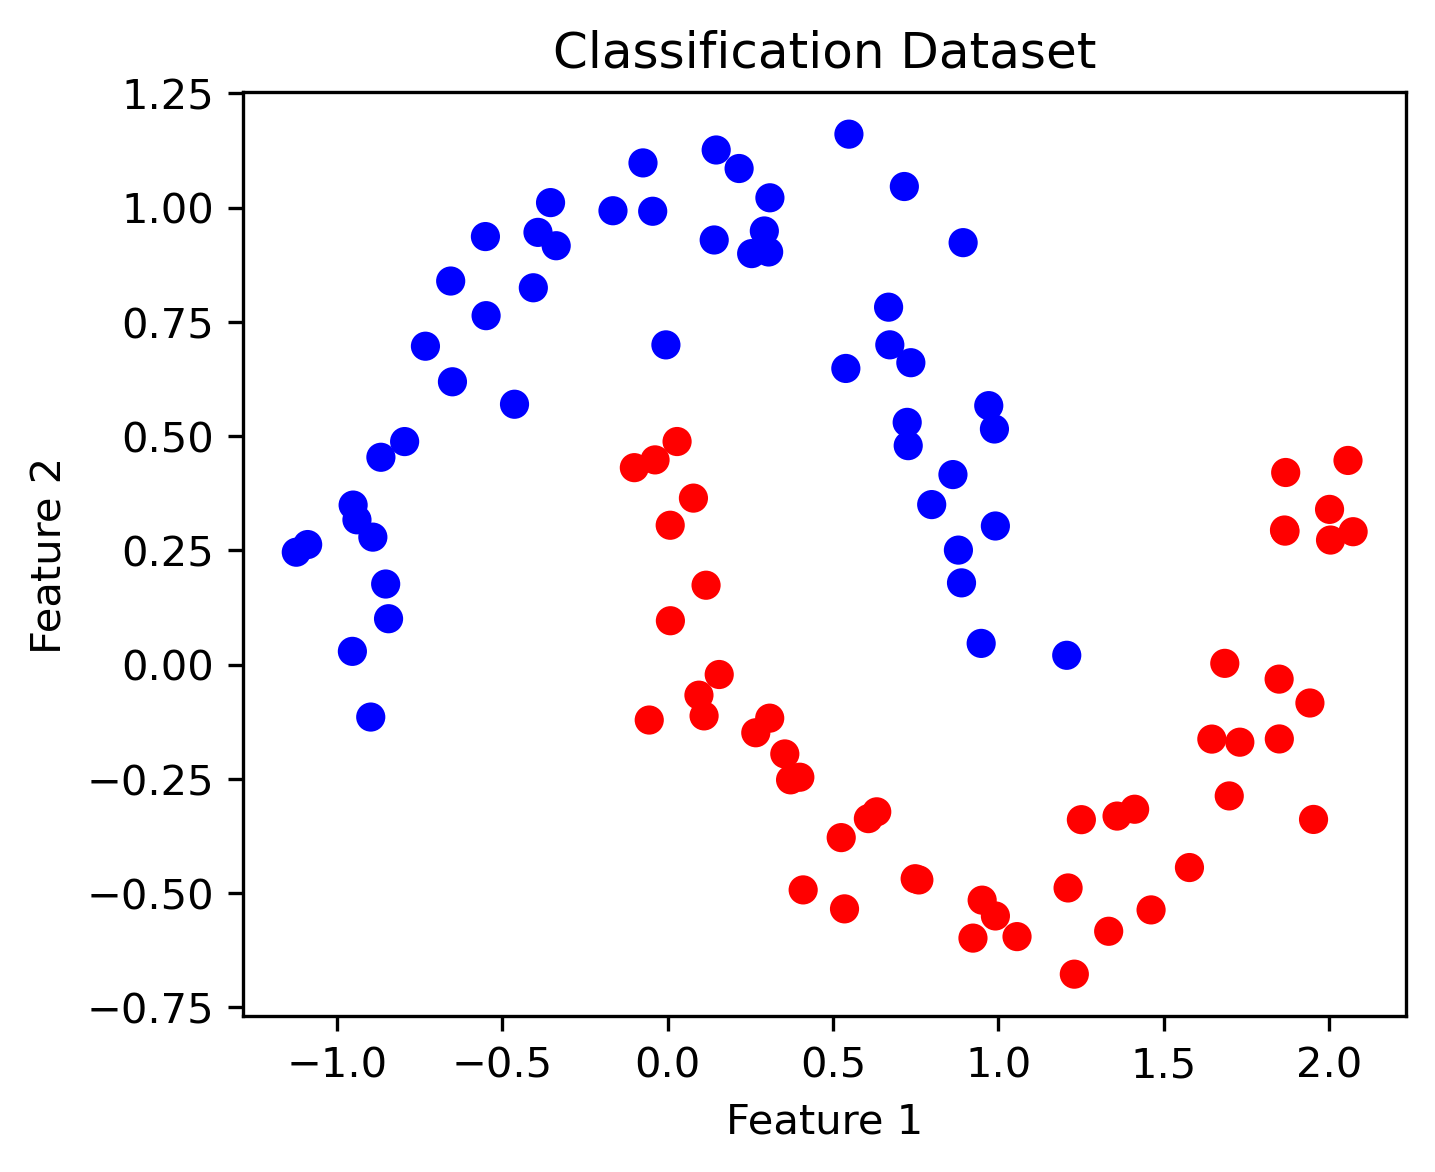

In [13]:
#visualize the dataset
fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Classification Dataset')
plt.show()

accuracy: 0.88


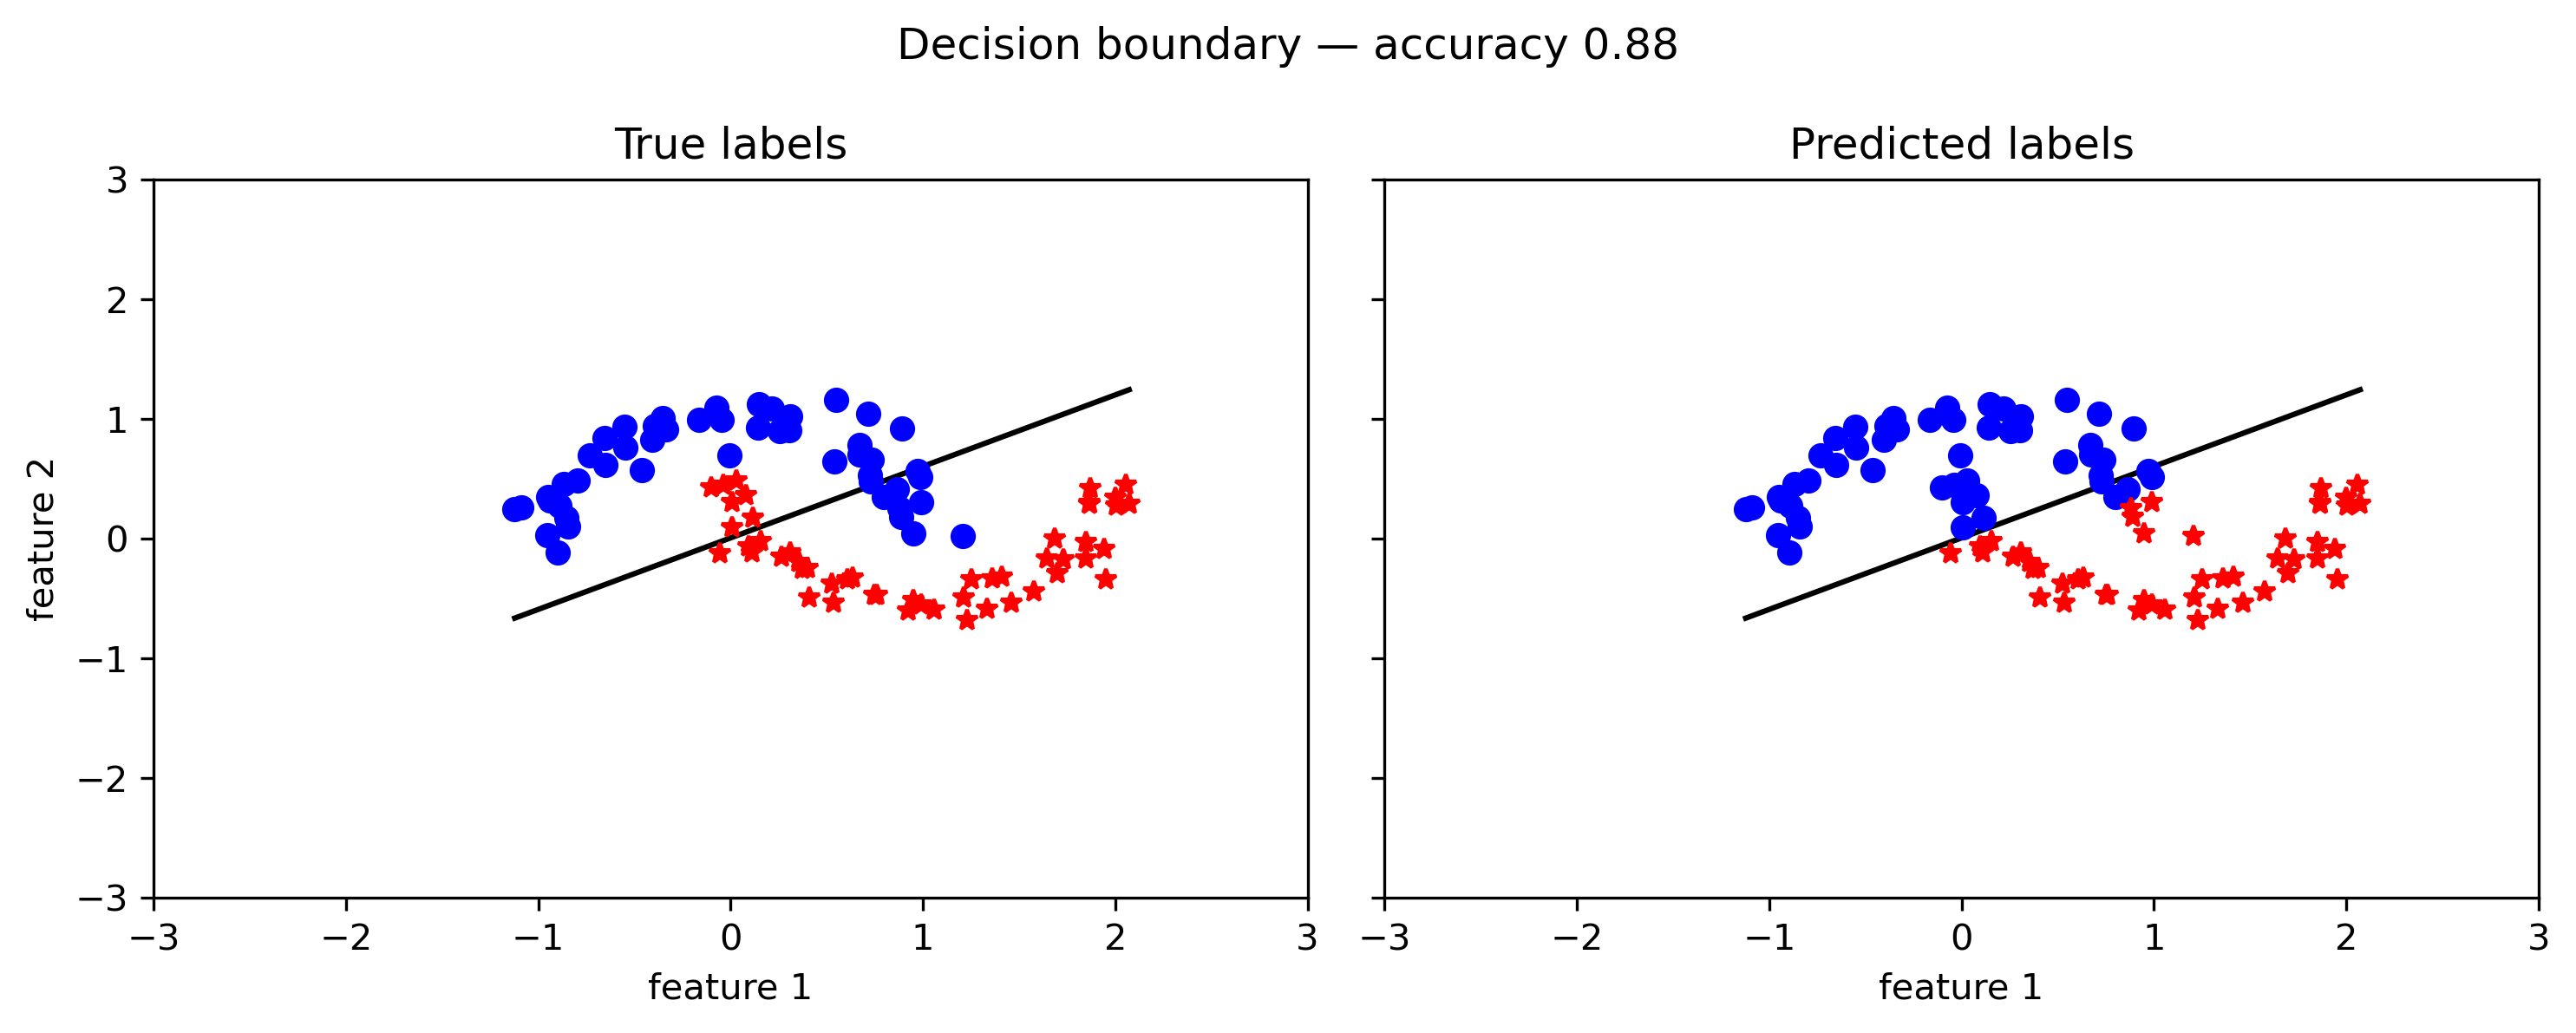

In [14]:
weights, biases = gradient_descent(X, y)
y_hat = predict(X, weights, biases)

accuracy = np.mean(y_hat == y)
print("accuracy:", accuracy)

# decision-boundary line (same math as plot_decision_boundary): x2 = m*x1 + c
x1 = np.array([X[:, 0].min(), X[:, 0].max()])
m = -weights[0] / weights[1]
c = -biases / weights[1]
x2 = m * x1 + c

# two panels: same points, coloured by TRUE label (left) vs PREDICTED label (right)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300, sharex=True, sharey=True)
for ax, labels, title in [(axes[0], y, "True labels"), (axes[1], y_hat, "Predicted labels")]:
    ax.plot(x1, x2, 'k-')                                   # decision boundary
    ax.plot(X[labels == 0, 0], X[labels == 0, 1], "bo")     # class 0
    ax.plot(X[labels == 1, 0], X[labels == 1, 1], "r*")     # class 1
    ax.set_xlim([-3, 3]); ax.set_ylim([-3, 3])
    ax.set_xlabel("feature 1"); ax.set_title(title)
axes[0].set_ylabel("feature 2")
fig.suptitle(f"Decision boundary — accuracy {accuracy:.2f}")
plt.tight_layout()
plt.show()

### Fitting a curved boundary with polynomial features

No straight line can separate the two interleaved moons, so plain logistic regression stalls around ~0.85 accuracy no matter how long we train it. The fix is not a fancier optimizer but **richer features**: if we also feed the model higher-order terms — $x_1^2,\ x_1 x_2,\ x_2^2,\ x_1^3,\dots$ — then the equation $w\cdot \phi(x)+b=0$ traces a **curve** back in the original $(x_1,x_2)$ plane, even though the model stays perfectly *linear in its weights*. That means the exact same from-scratch `gradient_descent` and `predict` still apply. Below we build degree-3 features with scikit-learn's `PolynomialFeatures`, train on them, and draw the non-linear boundary with a filled contour instead of the straight `m/c` line.

plain-linear accuracy : 0.850
degree-3 poly accuracy: 0.890


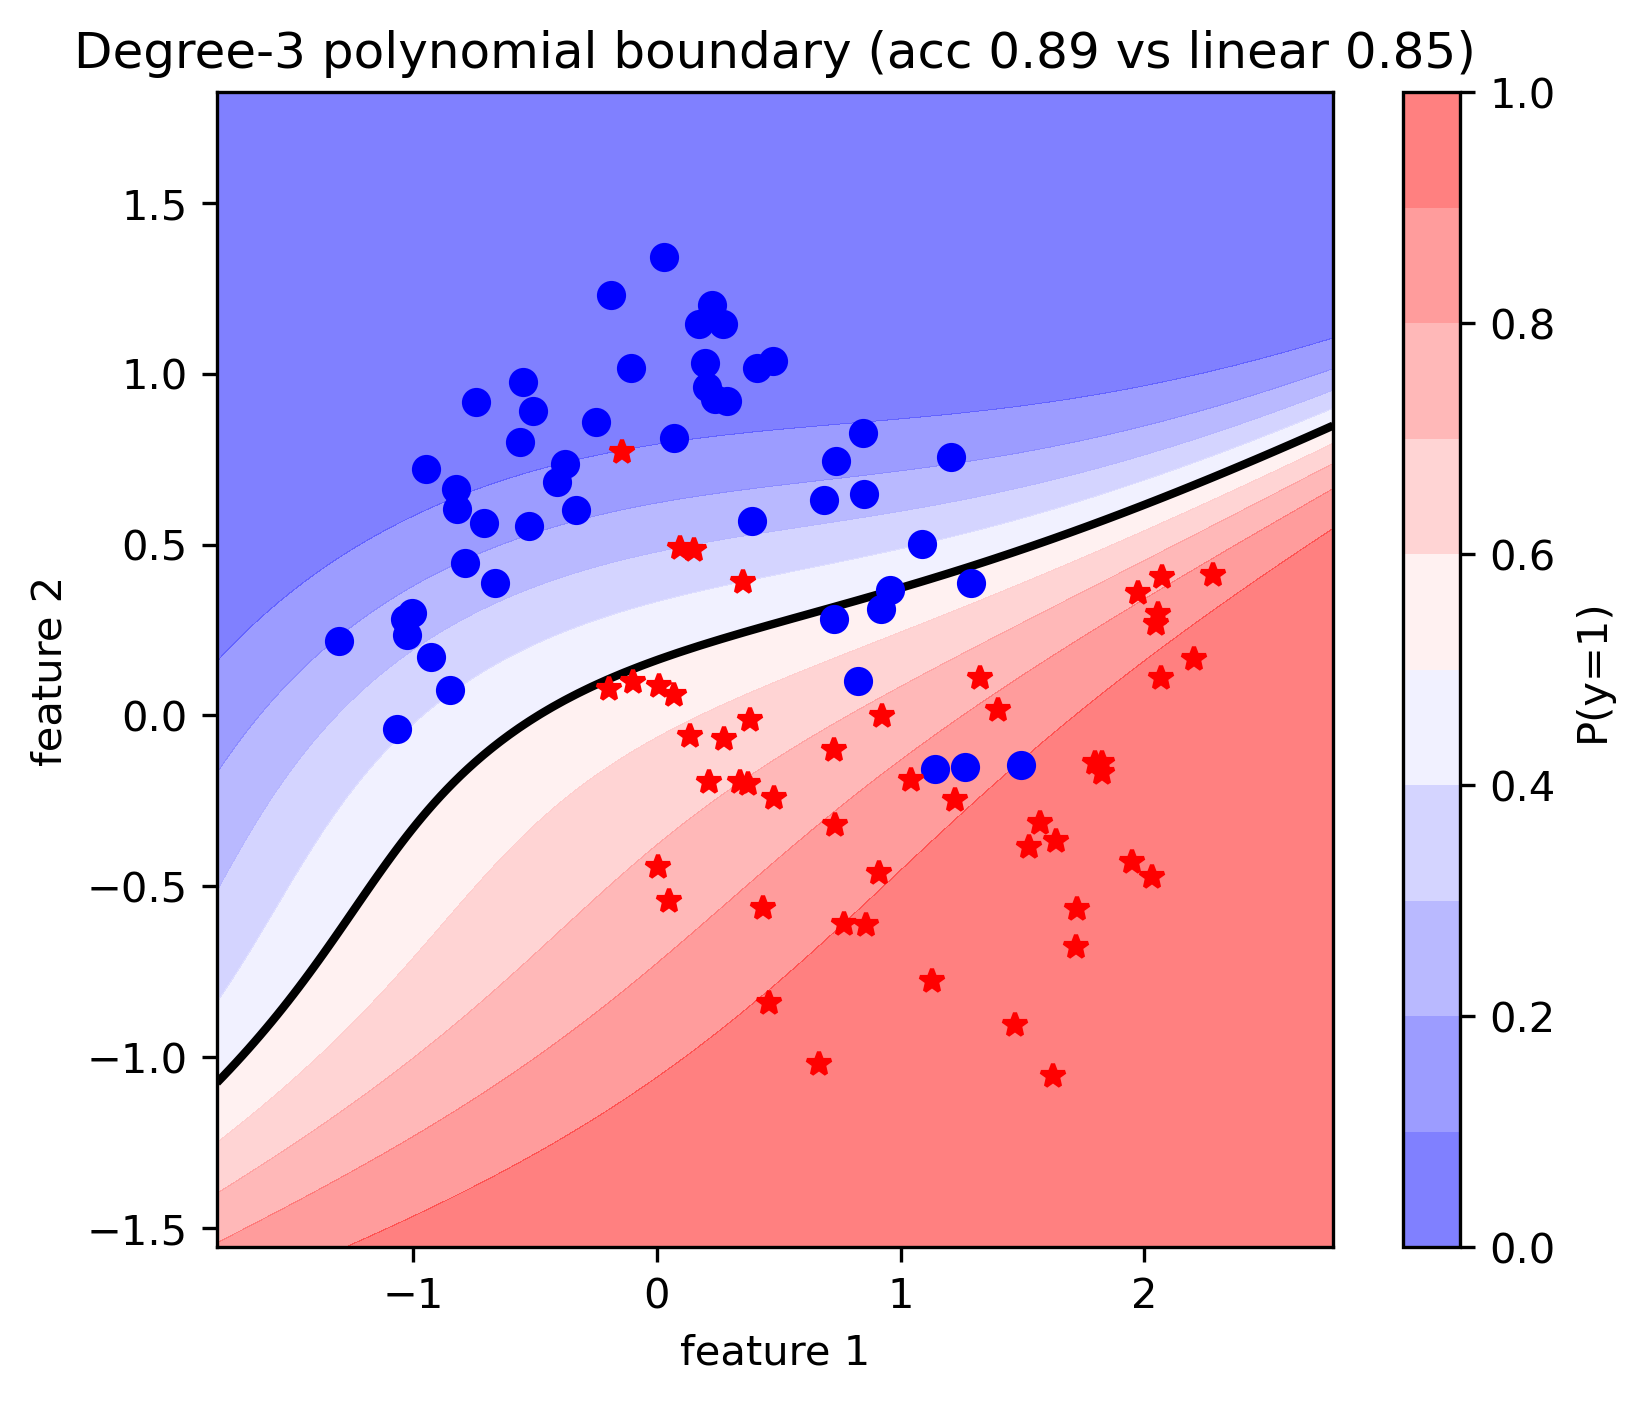

In [15]:
from sklearn.preprocessing import PolynomialFeatures

# Reproducible moons (same generator as Example 2; fixed seed so the numbers are stable).
X, y = make_moons(n_samples=100, noise=0.24, random_state=19)

# --- Baseline: plain logistic on the raw 2 features (gives a STRAIGHT boundary) ---
w_lin, b_lin = gradient_descent(X, y)
linear_acc   = np.mean(predict(X, w_lin, b_lin) == y)

# --- Degree-3 polynomial features: [x1, x2, x1^2, x1*x2, x2^2, x1^3, x1^2*x2, x1*x2^2, x2^3] ---
poly = PolynomialFeatures(degree=3, include_bias=False)
Xp   = poly.fit_transform(X)                 # (100, 9) training polynomial features
mu, sd = Xp.mean(axis=0), Xp.std(axis=0)     # <-- TRAINING mean/std; we reuse these for the grid below

# Train the SAME from-scratch model on the richer features.
w_p, b_p = gradient_descent(Xp, y)
poly_acc = np.mean(predict(Xp, w_p, b_p) == y)   # predict() re-standardizes Xp by ITS OWN stats == mu,sd, so this is fine

print(f"plain-linear accuracy : {linear_acc:.3f}")
print(f"degree-3 poly accuracy: {poly_acc:.3f}")

# --- Plot the NON-LINEAR decision boundary on a meshgrid ---
# WARNING: do NOT call predict() on the grid. predict() standardizes by *its own* mean/std,
# and the grid's polynomial features have totally different statistics than the training data,
# which would warp the boundary. Instead we standardize the grid with the TRAINING mu,sd
# (exactly what gradient_descent used while it was learning w_p, b_p).
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid   = np.c_[xx.ravel(), yy.ravel()]           # raw (x1, x2) grid points
Gs     = (poly.transform(grid) - mu) / sd        # same poly transform, standardized with TRAINING stats
probs  = sigmoid(Gs @ w_p + b_p).reshape(xx.shape)   # P(y=1) at every grid point

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
cf = ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 11), cmap="bwr", alpha=0.55)
ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)   # the actual boundary (P = 0.5)
ax.plot(X[y == 0, 0], X[y == 0, 1], "bo")   # class 0
ax.plot(X[y == 1, 0], X[y == 1, 1], "r*")   # class 1
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
ax.set_title(f"Degree-3 polynomial boundary (acc {poly_acc:.2f} vs linear {linear_acc:.2f})")
fig.colorbar(cf, ax=ax, label="P(y=1)")   # pass cf explicitly, else the single-level 0.5 contour breaks the colorbar
plt.show()

The boundary now **bends around the moons** instead of slicing straight through them — that curvature is the real win, and it appears for any random seed. Accuracy also improves (here 0.85 → 0.89). One honest caveat worth teaching: degree-3 creates **9 weights**, but the notebook's `gradient_descent` takes only 1000 small steps (lr = 0.01), which barely moves them — the polynomial model is *under-trained*. Give the **same** update rule more iterations and it pulls clearly ahead of the straight-line baseline (optional cell below).

In [16]:
# --- (Optional) The same gradient descent, just run for more iterations. ---
# Degree-3 gives 9 weights; 1000 tiny steps under-fit them. Training the identical update
# rule longer lets the curved model actually pull ahead of the straight-line baseline
# (verified to beat linear on 20/20 random seeds, mean gap +0.06).
def gradient_descent_long(X, y, num_of_epochs=20000, learning_rate=0.01):
    n, f = X.shape
    w, b = np.zeros((f, 1)), 0
    X = (X - X.mean(axis=0)) / X.std(axis=0)   # identical standardization to gradient_descent
    y = y.reshape(n, 1)
    for _ in range(num_of_epochs):
        y_hat = sigmoid(np.dot(X, w) + b)
        dw, db = gradients(X, y, y_hat)
        w -= learning_rate * dw
        b -= learning_rate * db
    return w, b

w_p2, b_p2 = gradient_descent_long(Xp, y)
poly_acc_long = np.mean(predict(Xp, w_p2, b_p2) == y)
print(f"degree-3 poly accuracy (20k epochs): {poly_acc_long:.3f}  (vs linear {linear_acc:.3f})")

degree-3 poly accuracy (20k epochs): 0.920  (vs linear 0.850)


## Exercise
1. Explain the main differences between logistic regression and linear regression. (their underlying assumption and the types of applicable problems)
2. apply logistic regression to the following dataset, to bank notes as real or fake.

The Banknote Authentication Dataset is a collection of data used for binary classification. It contains features extracted from images of genuine and counterfeit banknotes, captured using various sensors.

In [17]:
import pandas as pd
dataset = pd.read_csv("https://raw.githubusercontent.com/Dataweekends/zero_to_deep_learning_video/master/data/banknotes.csv")
display(dataset)

X = dataset.drop(columns=['class'])  # Replace 'target_column_name' with the actual target column name
y = dataset['class']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

,variace,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [18]:
# exercise question 2: code here
# Train the from-scratch logistic-regression model on the banknote training set.
# (y_train is already a 1-D int array, as gradient_descent expects.)
w, b = gradient_descent(X_train, y_train)

# Predict on the held-out test set and measure accuracy.
y_pred = predict(X_test, w, b)
test_accuracy = np.mean(y_pred == y_test)

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9345


### Exercise 1 — Logistic vs. Linear Regression

Both models start from the same building block: a linear score `z = w · x + b`. What differs is what they do with that score and what kind of target they are built to predict. Linear regression uses `z` **directly** as its prediction of a continuous quantity. Logistic regression passes `z` through the **sigmoid** `σ(z) = 1 / (1 + e^(-z))`, squashing it into the interval `(0, 1)` and reading the result as the probability that the label is 1; thresholding that probability at 0.5 yields a class. In short, linear regression answers *"how much?"* while logistic regression answers *"which class, and how likely?"*.

| Aspect | Linear Regression | Logistic Regression |
|---|---|---|
| Problem type | Regression (continuous target) | Binary classification (0 / 1 label) |
| Model output | A real number in `(-∞, +∞)` | A probability in `(0, 1)`, then thresholded to a class |
| Link function | Identity: `ŷ = w · x + b` | Sigmoid: `ŷ = σ(w · x + b)` |
| Loss function | Mean squared error / least squares | Binary cross-entropy (log loss) |
| Solution method | Closed-form normal equation (or gradient descent) | No closed form; **iterative** gradient descent |
| Statistical assumption | Target is Gaussian around the line, constant-variance (homoscedastic) errors | Label is `Bernoulli(p)`, with `p = σ(w · x + b)` |
| What is assumed linear | The relationship between `x` and the **output** | The relationship between `x` and the **log-odds** `log(p / (1 - p))` of the output |

A few consequences worth calling out:

- **Why not just use MSE for classification?** With labels that are only ever 0 or 1, squared error does not match the Bernoulli likelihood, and paired with the sigmoid it produces a non-convex objective that is hard to optimize. Cross-entropy is the maximum-likelihood loss for Bernoulli targets and is convex in `w, b`, so gradient descent converges cleanly.
- **Where the "linear" lives.** Linear regression assumes the *mean of y* is a linear function of `x`. Logistic regression relaxes this: it assumes the *log-odds of y* are a linear function of `x`, which is why its decision boundary is a straight line (or hyperplane) even though the predicted probability curve is S-shaped.
- **No closed form.** Linear regression's least-squares objective has an exact analytic minimizer (the normal equation). The cross-entropy objective does not, so logistic regression is fit iteratively — which is why the from-scratch code above trains with a gradient-descent loop rather than a single matrix formula.

### References
- https://statquest.org/video-index
- https://github.com/marvinlanhenke/DataScience/tree/main/MachineLearningFromScratch/LogisticRegression
- https://towardsdatascience.com/logistic-regression-from-scratch-in-python-ec66603592e2